<a href="https://colab.research.google.com/github/SholaSaliu/multiple_linear_regression_project/blob/main/multiple_regression_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Multiple Linear Regression Analysis
## Marketing Sales Data Analysis

This notebook analyzes a multi-channel marketing dataset using Multiple Linear Regression to understand how different marketing channels jointly affect business outcomes.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

## 1. Data Loading and Exploration

In [4]:
# Load the dataset
df = pd.read_csv('marketing_sales_data.csv')

# Display the first 5 rows of the DataFrame
print('First 5 rows of the dataset:')
display(df.head())

print(f'\nDataset shape: {df.shape}')

First 5 rows of the dataset:


,TV,Radio,Social Media,Influencer,Sales
0,Low,3.518070,2.293790,Micro,55.261284
1,Low,7.756876,2.572287,Mega,67.574904
2,High,20.348988,1.227180,Micro,272.250108
3,Medium,20.108487,2.728374,Mega,195.102176
4,High,31.653200,7.776978,Nano,273.960377



Dataset shape: (572, 5)


In [5]:
# Check for missing values
print('Missing values per column:')
print(df.isnull().sum())

# Display data types and non-null values
print('\nDataFrame Info:')
df.info()

# Display descriptive statistics for numerical columns
print('\nDescriptive statistics:')
display(df.describe())

Missing values per column:
TV              0
Radio           0
Social Media    0
Influencer      0
Sales           0
dtype: int64

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 572 entries, 0 to 571
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   TV            572 non-null    object 
 1   Radio         572 non-null    float64
 2   Social Media  572 non-null    float64
 3   Influencer    572 non-null    object 
 4   Sales         572 non-null    float64
dtypes: float64(3), object(2)
memory usage: 22.5+ KB

Descriptive statistics:


,Radio,Social Media,Sales
count,572.000000,572.000000,572.000000
mean,17.520616,3.333803,189.296908
std,9.290933,2.238378,89.871581
min,0.109106,0.000031,33.509810
25%,10.699556,1.585549,118.718722
50%,17.149517,3.150111,184.005362
75%,24.606396,4.730408,264.500118
max,42.271579,11.403625,357.788195


## 2. Data Preprocessing and Encoding

In [6]:
# Perform one-hot encoding for categorical variables 'TV' and 'Influencer'
df_encoded = pd.get_dummies(df, columns=['TV', 'Influencer'], drop_first=True)

# Display the first 5 rows of the encoded DataFrame
print('DataFrame after one-hot encoding:')
display(df_encoded.head())

print(f'\nEncoded columns: {list(df_encoded.columns)}')

DataFrame after one-hot encoding:


,Radio,Social Media,Sales,TV_Low,TV_Medium,Influencer_Mega,Influencer_Micro,Influencer_Nano
0,3.518070,2.293790,55.261284,True,False,False,True,False
1,7.756876,2.572287,67.574904,True,False,True,False,False
2,20.348988,1.227180,272.250108,False,False,False,True,False
3,20.108487,2.728374,195.102176,False,True,True,False,False
4,31.653200,7.776978,273.960377,False,False,False,False,True



Encoded columns: ['Radio', 'Social Media', 'Sales', 'TV_Low', 'TV_Medium', 'Influencer_Mega', 'Influencer_Micro', 'Influencer_Nano']


## 3. Multicollinearity Analysis

Correlation Matrix of Independent Variables:


,Radio,Social Media,TV_Low,TV_Medium,Influencer_Mega,Influencer_Micro,Influencer_Nano
Radio,1.000000,0.626424,-0.674382,0.004024,0.037074,0.001184,0.015001
Social Media,0.626424,1.000000,-0.416993,-0.015014,0.063592,-0.046799,0.016884
TV_Low,-0.674382,-0.416993,1.000000,-0.550117,-0.052697,0.016107,0.006815
TV_Medium,0.004024,-0.015014,-0.550117,1.000000,0.067488,0.007302,-0.059374
Influencer_Mega,0.037074,0.063592,-0.052697,0.067488,1.000000,-0.336096,-0.345177
Influencer_Micro,0.001184,-0.046799,0.016107,0.007302,-0.336096,1.000000,-0.368361
Influencer_Nano,0.015001,0.016884,0.006815,-0.059374,-0.345177,-0.368361,1.000000


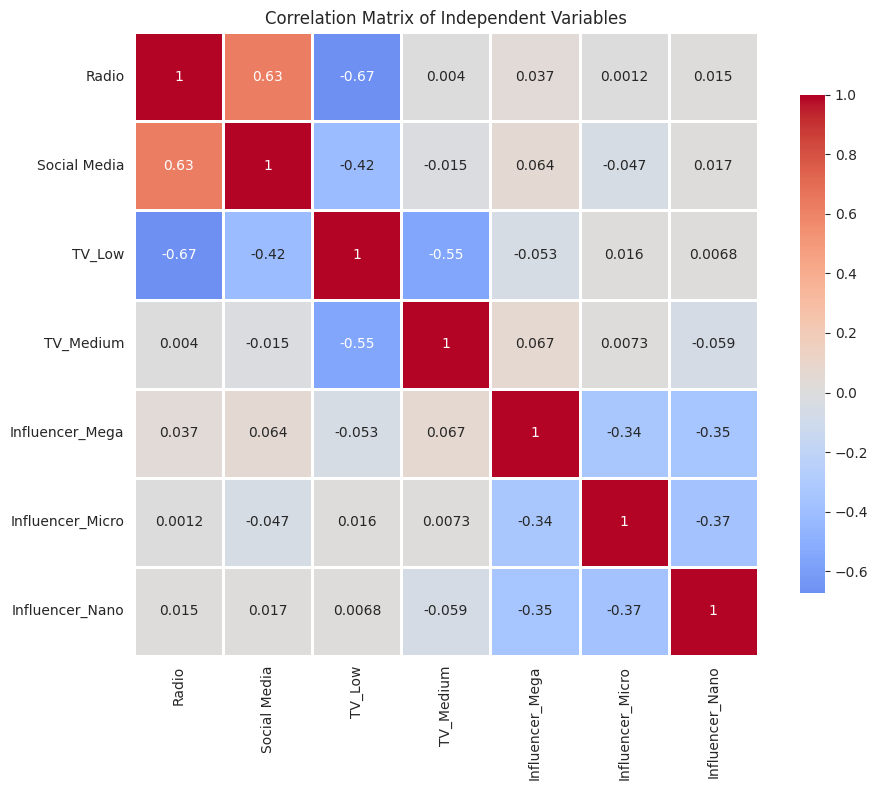


Variance Inflation Factor (VIF):


,feature,VIF
0,Radio,6.043441
1,Social Media,4.352831
5,Influencer_Micro,2.080373
6,Influencer_Nano,2.075958
4,Influencer_Mega,1.990339
3,TV_Medium,1.656176
2,TV_Low,1.655608



VIF Interpretation:
VIF < 5: Low multicollinearity (acceptable)
VIF >= 5: High multicollinearity (concerning)


In [7]:
# Identify independent variables for VIF calculation
X = df_encoded.drop('Sales', axis=1)

# Convert boolean columns to integer (0 or 1) for VIF calculation
X = X.astype(int)

# Calculate the correlation matrix
print('Correlation Matrix of Independent Variables:')
correlation_matrix = X.corr()
display(correlation_matrix)

# Visualize correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix of Independent Variables')
plt.tight_layout()
plt.show()

# Calculate VIF for each independent variable
vif_data = pd.DataFrame()
vif_data['feature'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]

print('\nVariance Inflation Factor (VIF):')
vif_sorted = vif_data.sort_values(by='VIF', ascending=False)
display(vif_sorted)

print('\nVIF Interpretation:')
print('VIF < 5: Low multicollinearity (acceptable)')
print('VIF >= 5: High multicollinearity (concerning)')

## 4. Multiple Linear Regression Model

In [8]:
# Prepare the data for modeling
X_with_const = sm.add_constant(X)
y = df_encoded['Sales']

# Build the OLS regression model
model = sm.OLS(y, X_with_const).fit()

# Display model summary
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.904
Model:                            OLS   Adj. R-squared:                  0.903
Method:                 Least Squares   F-statistic:                     762.9
Date:                Sun, 21 Jun 2026   Prob (F-statistic):          7.83e-283
Time:                        15:55:52   Log-Likelihood:                -2712.6
No. Observations:                 572   AIC:                             5441.
Df Residuals:                     564   BIC:                             5476.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const              218.5646      6.469  

## 5. Model Evaluation and Diagnostics

In [9]:
# Extract key metrics
r_squared = model.rsquared
adj_r_squared = model.rsquared_adj
f_statistic = model.fvalue
f_pvalue = model.f_pvalue

print('Model Performance Metrics:')
print(f'R-squared: {r_squared:.4f}')
print(f'Adjusted R-squared: {adj_r_squared:.4f}')
print(f'F-statistic: {f_statistic:.4f}')
print(f'F-statistic p-value: {f_pvalue:.4e}')

# Get predictions
y_pred = model.predict(X_with_const)
residuals = model.resid

# Calculate RMSE
rmse = np.sqrt(mean_squared_error(y, y_pred))
print(f'\nRoot Mean Squared Error (RMSE): {rmse:.4f}')

Model Performance Metrics:
R-squared: 0.9045
Adjusted R-squared: 0.9033
F-statistic: 762.8982
F-statistic p-value: 7.8277e-283

Root Mean Squared Error (RMSE): 27.7523


## 6. Residual Analysis and Assumptions

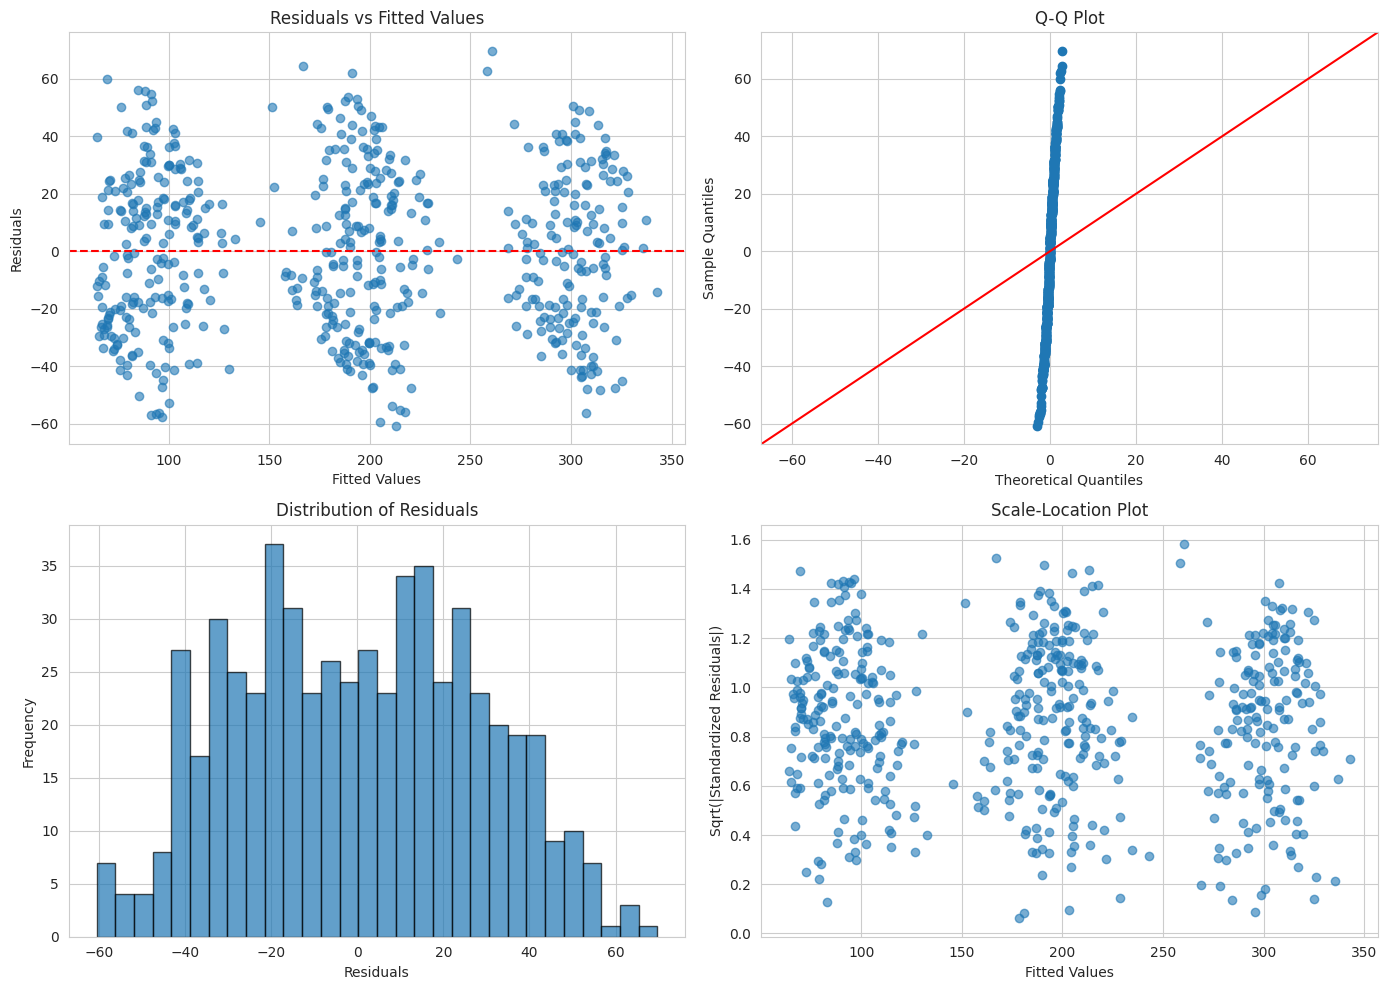

Residual Analysis Summary:
Mean of residuals: -1.1294e-13
Std of residuals: 27.7765


In [10]:
# Create diagnostic plots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Residuals vs Fitted
axes[0, 0].scatter(y_pred, residuals, alpha=0.6)
axes[0, 0].axhline(y=0, color='r', linestyle='--')
axes[0, 0].set_xlabel('Fitted Values')
axes[0, 0].set_ylabel('Residuals')
axes[0, 0].set_title('Residuals vs Fitted Values')

# Q-Q plot
sm.qqplot(residuals, line='45', ax=axes[0, 1])
axes[0, 1].set_title('Q-Q Plot')

# Histogram of residuals
axes[1, 0].hist(residuals, bins=30, edgecolor='black', alpha=0.7)
axes[1, 0].set_xlabel('Residuals')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Distribution of Residuals')

# Scale-Location plot
standardized_residuals = residuals / residuals.std()
axes[1, 1].scatter(y_pred, np.sqrt(np.abs(standardized_residuals)), alpha=0.6)
axes[1, 1].set_xlabel('Fitted Values')
axes[1, 1].set_ylabel('Sqrt(|Standardized Residuals|)')
axes[1, 1].set_title('Scale-Location Plot')

plt.tight_layout()
plt.show()

print('Residual Analysis Summary:')
print(f'Mean of residuals: {residuals.mean():.4e}')
print(f'Std of residuals: {residuals.std():.4f}')

## 7. Model Interpretation and Recommendations

In [11]:
# Coefficient interpretation
coefficients = model.params
pvalues = model.pvalues

coef_df = pd.DataFrame({
    'Coefficient': coefficients,
    'P-value': pvalues,
    'Significant': ['Yes' if p < 0.05 else 'No' for p in pvalues]
})

print('Model Coefficients and Significance:')
display(coef_df)

print('\nInterpretation:')
print('Coefficients represent the change in Sales for a one-unit increase in each variable,')
print('holding all other variables constant.')
print('\nSignificant variables (p < 0.05) have a statistically meaningful impact on Sales.')

Model Coefficients and Significance:


,Coefficient,P-value,Significant
const,218.564646,1.201757e-137,Yes
Radio,2.994216,5.355314e-33,Yes
Social Media,-0.209779,7.559221e-01,No
TV_Low,-154.249744,8.212135e-125,Yes
TV_Medium,-75.401357,3.769644e-71,Yes
Influencer_Mega,2.408718,4.861059e-01,No
Influencer_Micro,2.925741,3.860853e-01,No
Influencer_Nano,0.807815,8.089758e-01,No



Interpretation:
Coefficients represent the change in Sales for a one-unit increase in each variable,
holding all other variables constant.

Significant variables (p < 0.05) have a statistically meaningful impact on Sales.


## 8. Visualizations and Insights

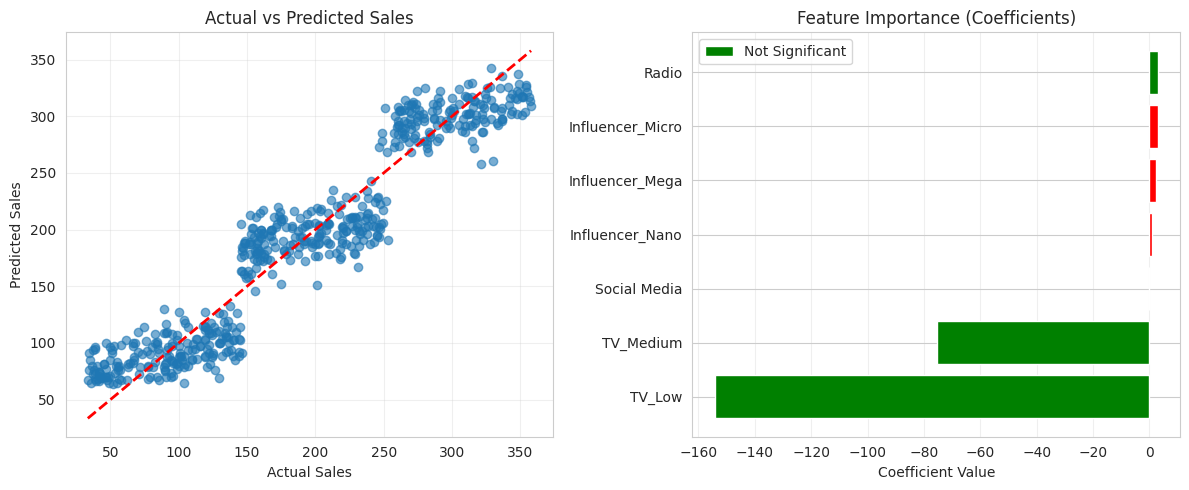

In [12]:
# Plot actual vs predicted
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(y, y_pred, alpha=0.6)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
plt.xlabel('Actual Sales')
plt.ylabel('Predicted Sales')
plt.title('Actual vs Predicted Sales')
plt.grid(True, alpha=0.3)

# Coefficient importance
plt.subplot(1, 2, 2)
coef_sorted = coef_df.drop('const').sort_values('Coefficient')
colors = ['red' if x == 'No' else 'green' for x in coef_sorted['Significant']]
plt.barh(coef_sorted.index, coef_sorted['Coefficient'], color=colors)
plt.xlabel('Coefficient Value')
plt.title('Feature Importance (Coefficients)')
plt.legend(['Not Significant', 'Significant'], loc='best')
plt.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

## 9. Conclusions and Business Recommendations

### Key Findings:
1. **Model Fit**: The model's R-squared value indicates how well marketing variables explain sales variations.
2. **Multicollinearity**: VIF analysis shows which variables are highly correlated.
3. **Significant Predictors**: Only variables with p-values < 0.05 significantly impact sales.
4. **Residual Assumptions**: Check if residuals are normally distributed and homoscedastic.

### Recommendations for Marketing Budget Allocation:
- **Focus on high-impact channels**: Allocate more budget to variables with positive, significant coefficients.
- **Monitor multicollinearity**: High VIF values suggest channels are correlated; consider their combined effect.
- **Data-driven decisions**: Use coefficient magnitudes to determine relative investment in each channel.
- **Validate assumptions**: Ensure model assumptions hold before making critical business decisions.